# Summary
- [Methodology and Procedure](#methodology-and-procedure)
- [Fitts' Plots](#fitts-plots)
- [Steering Plots](#steering-plots)
- [Results](#results)
- [Problems](#problems)

# Methodology and Procedure

### Fitts' Law
For Fitts law a standard layout of 10 Circles was chosen with Targetsizes [30, 55, 80] and Distances (radius) [300, 400, 500] .  
Each combination of conditions was repeated 3times per participant.
The orientation/Rotation of the cirlces was randomised for each condition. As well as the direction the circle to click "wanders" clockwise vs counterclockwise.
Missclicks were also recorded.  
Participants primed a round by pressing **_S_** to make sure they are ready, then the first circle appeared and on click logged timestamp, etc.  

For the Analysis the movement-time between the single dots was taken and for Missclicks the sum of all missclicks of one iteration were calculated. Then the mean of those values across the 3 iterations was taken.
To compare the different Input-Methods the Througput of the Input-Method was calculated, the complete missclicks and the Ratio of Movement-Time to Missclicks.

### Steering Law
For Steering Law each combination of conditons was also teste 3 times with a randomized order of conditions. Tunneldistances were [500, 800, 1100] with heights beeing [50, 80, 110].  
Participants primed a round by pressing **_S_** to make sure they are ready, then the real trial starts when a movement across the tunnel entrance is registered and ends when the exit is crossed. During the Mouse-movement event of pyglet is logged. Logging also includes hits to the tunnel walls.  
  

For the Analysis the movement time across the tunnel was taken and the sum of all wall-hits, then again the mean of those values across the three iterations.
For comparison of Input-Methods I again calculated the Througput, the sum of Hits and the comparison of Movement-Time to Hits.


# Fitts' Plots
Following the Plots for the analysis of Fitts' Law

In [56]:
#Imports
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

fitts_Path = "data/fitts"
steering_Path = "data/steering"

#Notes:
# - Code was created with support of the local gemma-4 26b model (and succesively copied and adapted for the other cells)
#   Mainly the .agg parts

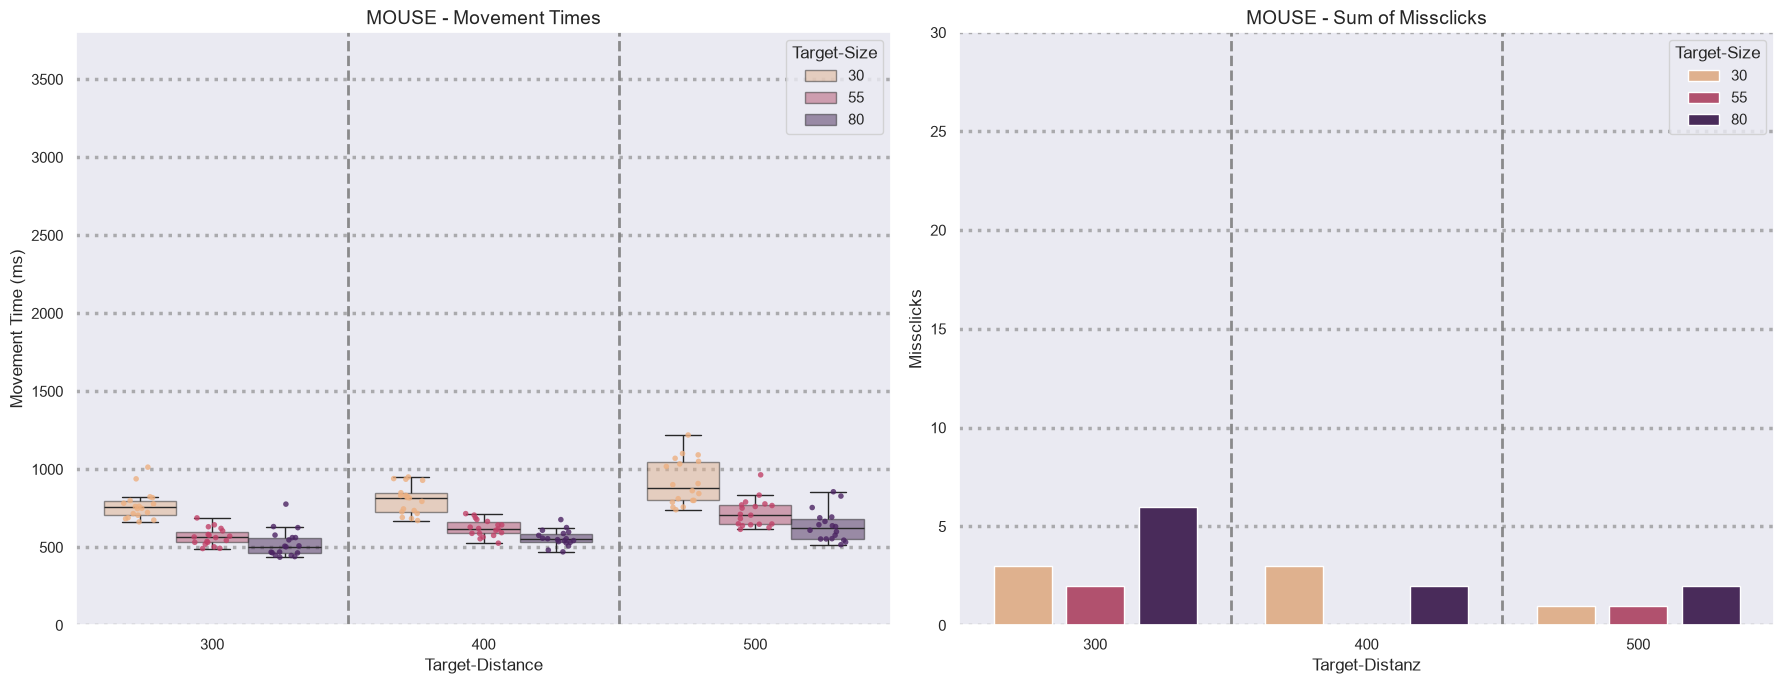

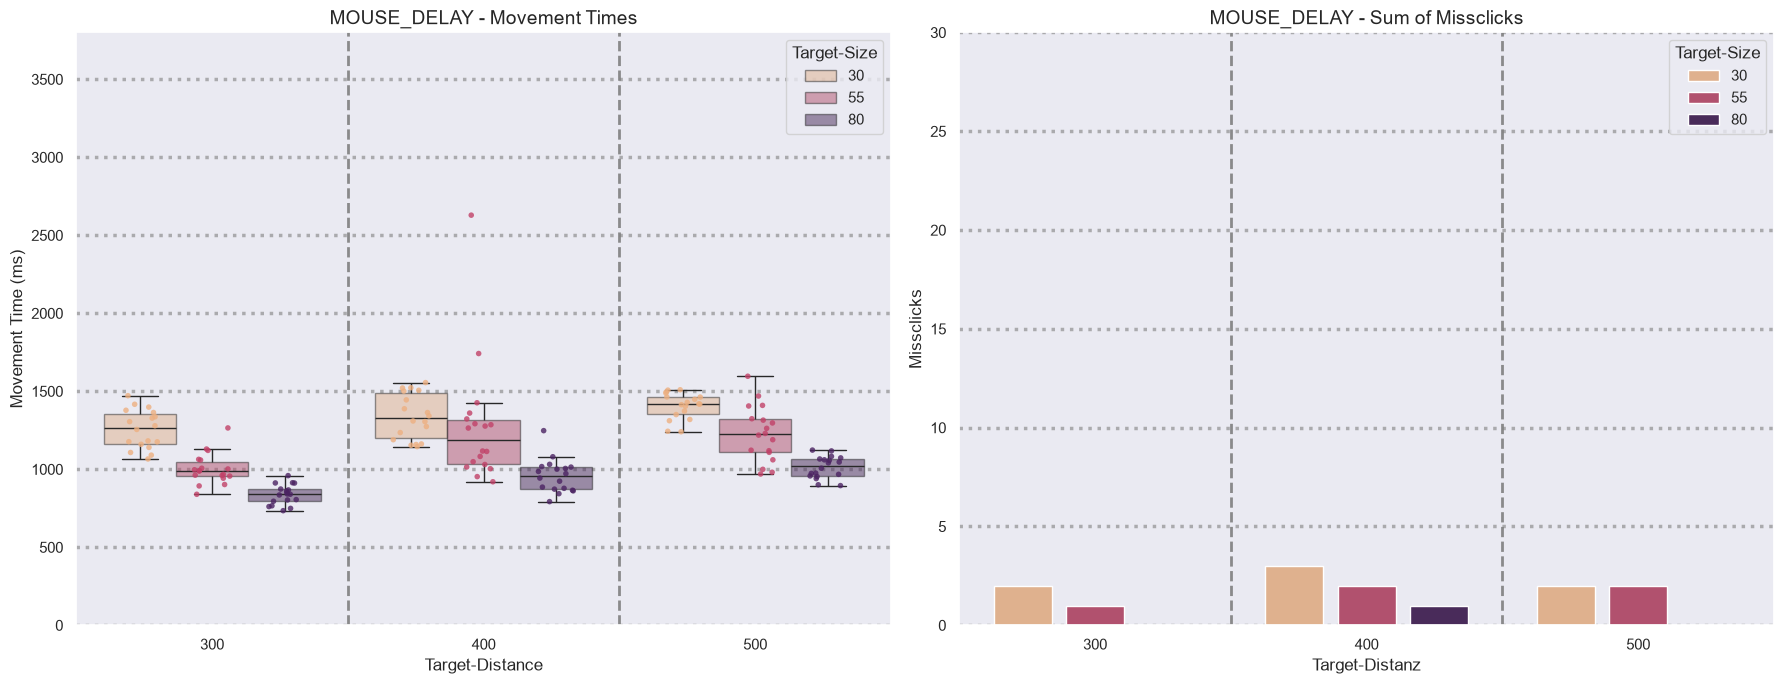

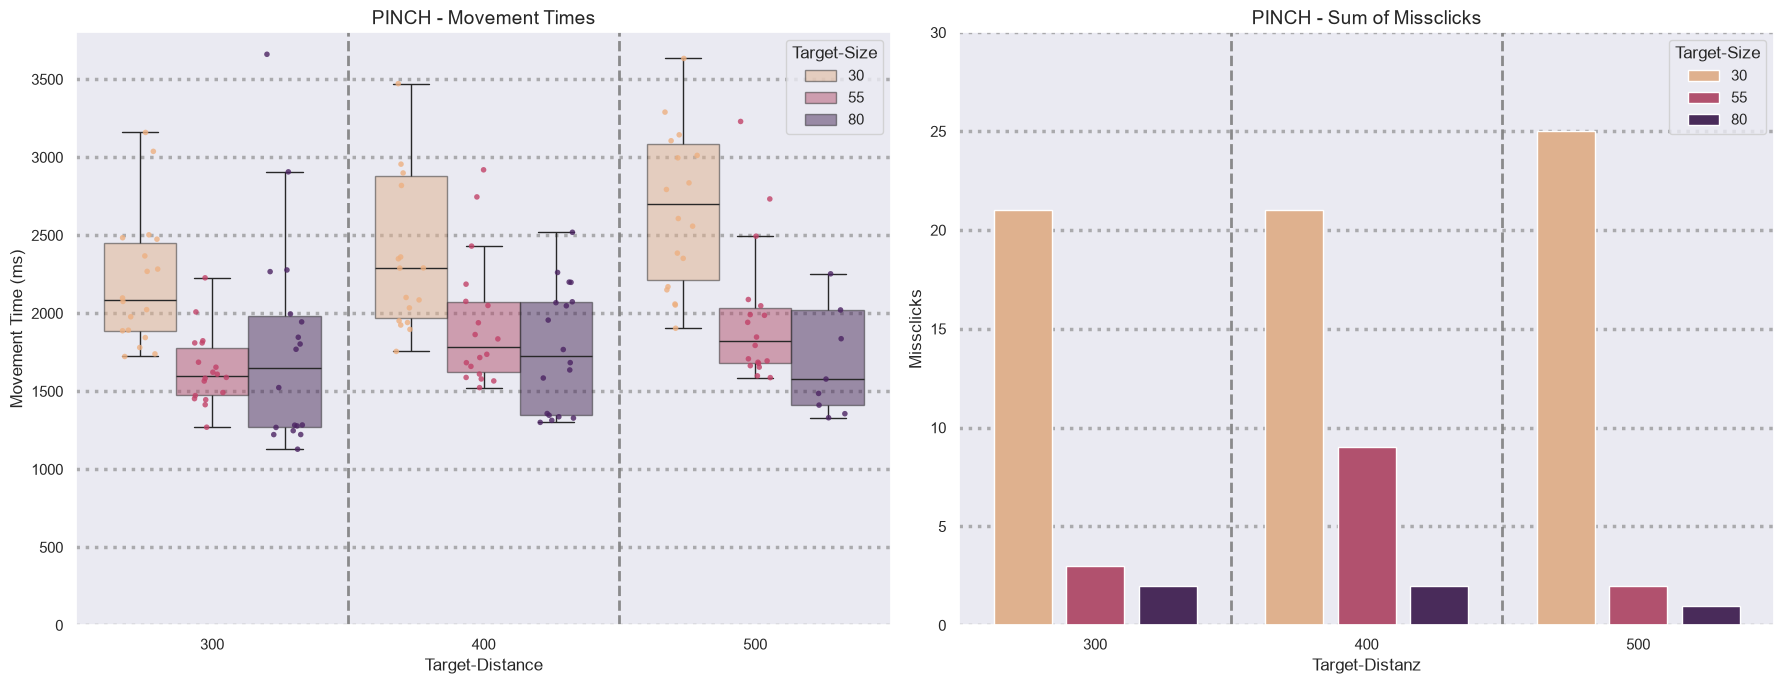

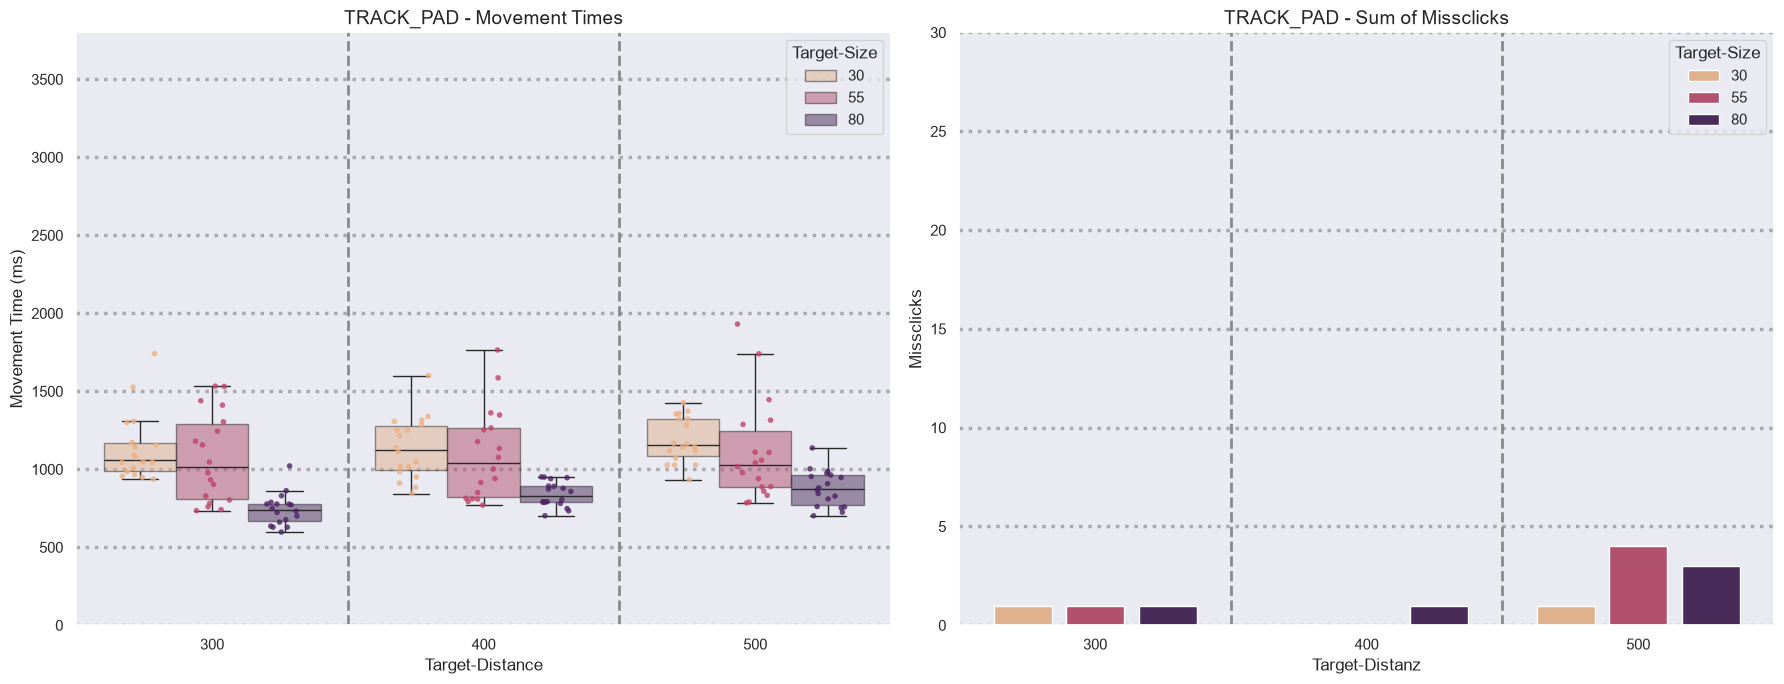

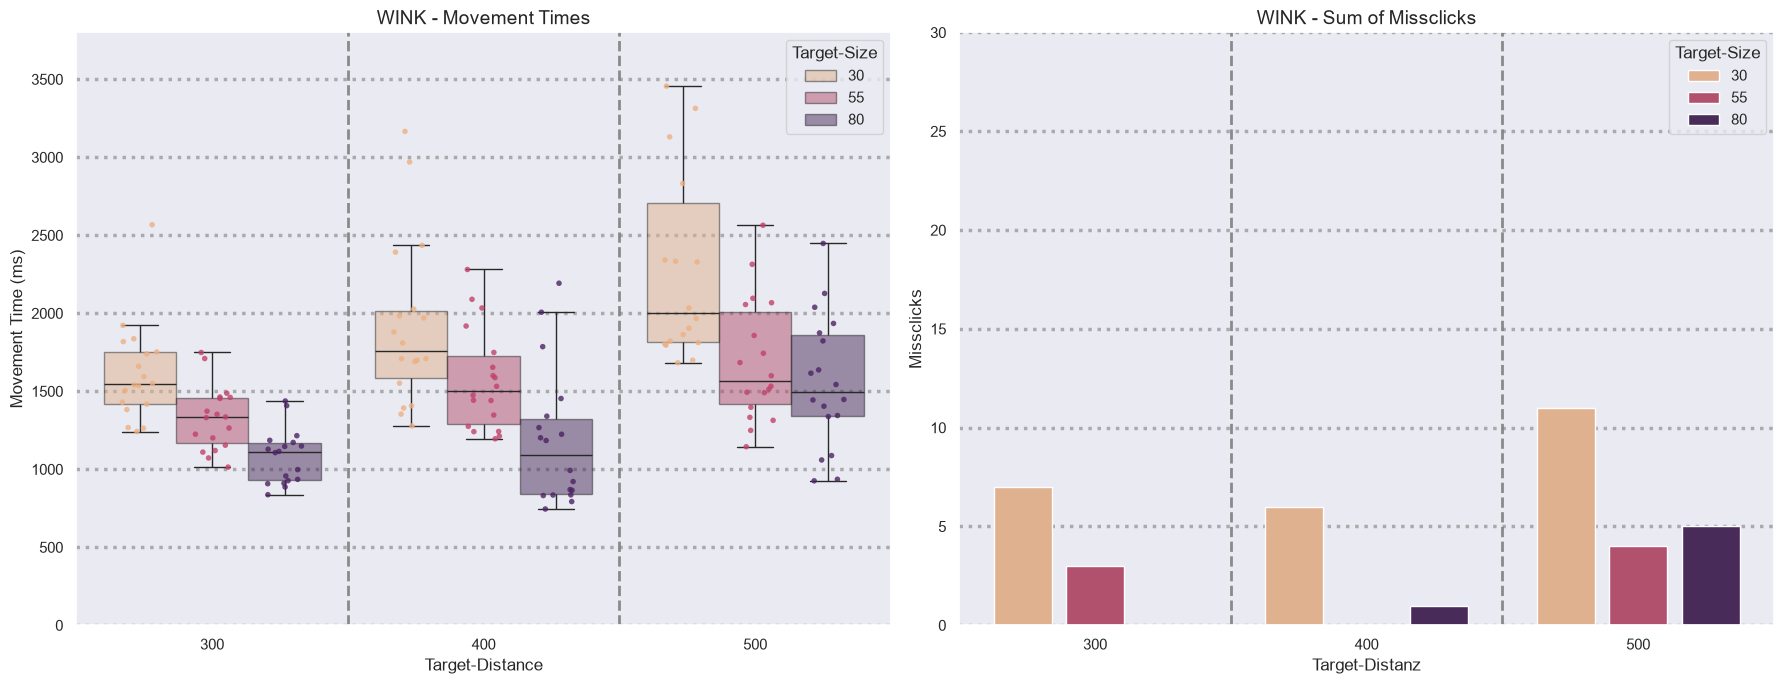

In [61]:
#Code for Input-Methods seperat
def showPlotPerInput(path):
    file_list = glob.glob(f"{path}/fitts_*.csv")
    all_data = []

    for file in file_list:
        df = pd.read_csv(file, sep=";")

        input_name = df["input_mode"][0]

        #seperates the iterations in one file and calculates the diff-time between targetclicks => then drops the first one which can't be calculated due to missing one before (pid could be left out)
        #sets the calculated mt as new column
        df["mt"] = df.groupby(["pid","iteration"])["timestamp"].transform(lambda x: x.diff())
        df = df.dropna(subset=["mt"])

        all_data.append(df)

    sorted_df = pd.concat(all_data, ignore_index=True)

    #Transform Data
    #group all data by the differrent variables and calculate the mean of mt for them (shrinks the data to mean per targetclick so for 3 persons there should be 27points per condition/9 per person(e.g. width=30,distance=300), so times 9 for each condition should be 243 points total)
    user_target_df = (
        sorted_df.groupby(["pid", "target_d", "target_w", "target_id"])["mt"]
        .mean()
        .reset_index()
    )

    #groups by condition and calculates the absolut sum of missclicks for the condition (independent of participants and iterations)
    missclicks_sum_df = (
        sorted_df.groupby(["target_d", "target_w"])["miss_clicks"]
        .sum()
        .reset_index()
    )
    
    #Plots
    sns.set_theme(style="darkgrid", rc={"grid.linewidth": 2.5})
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    #Movement-Time
    axes[0].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)
    sns.boxplot(
        ax=axes[0],
        data=user_target_df,
        x="target_d",
        y="mt",
        hue="target_w",
        palette="flare",
        showfliers=False,
        boxprops=dict(alpha=0.5, zorder=2),
    )
    sns.stripplot(
        ax=axes[0],
        data=user_target_df,
        x="target_d",
        y="mt",
        hue="target_w",
        palette="flare",
        alpha=0.8,
        size=4,  
        jitter=0.2,
        dodge=True,
        legend=False,
        zorder=3,
    )

    #seperators were also genrated with help of gemma-4 26b
    for i in range(len(missclicks_sum_df["target_d"].unique()) - 1):
        axes[0].axvline(
            x=i + 0.5, color="gray", linestyle="--", alpha=0.9, linewidth=2
        )

    axes[0].set_title(f"{input_name} - Movement Times",fontsize=14)
    axes[0].set_xlabel("Target-Distance", fontsize=12)
    axes[0].set_ylabel("Movement Time (ms)", fontsize=12)
    axes[0].set_ylim(0,3800)
    axes[0].legend(title="Target-Size", fontsize=11)

    #Missclicks
    axes[1].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)

    sns.barplot(
        ax=axes[1],
        data=missclicks_sum_df,
        x="target_d",
        y="miss_clicks",
        hue="target_w",
        palette="flare",
        gap=0.2,
        zorder=2,  
    )
    for i in range(len(missclicks_sum_df["target_d"].unique()) - 1):
        axes[1].axvline(
            x=i + 0.5, color="gray", linestyle="--", alpha=0.9, linewidth=2
        )

    axes[1].set_title(f"{input_name} - Sum of Missclicks",fontsize=14,)
    axes[1].set_xlabel("Target-Distanz", fontsize=12)
    axes[1].set_ylabel("Missclicks", fontsize=12)
    axes[1].set_ylim(0,30)
    axes[1].legend(title="Target-Size", fontsize=11)

    plt.tight_layout()
    plt.show()


for file in os.listdir(fitts_Path):
    path = f"{fitts_Path}/{file}"
    if os.path.isdir(path): 
        showPlotPerInput(path)

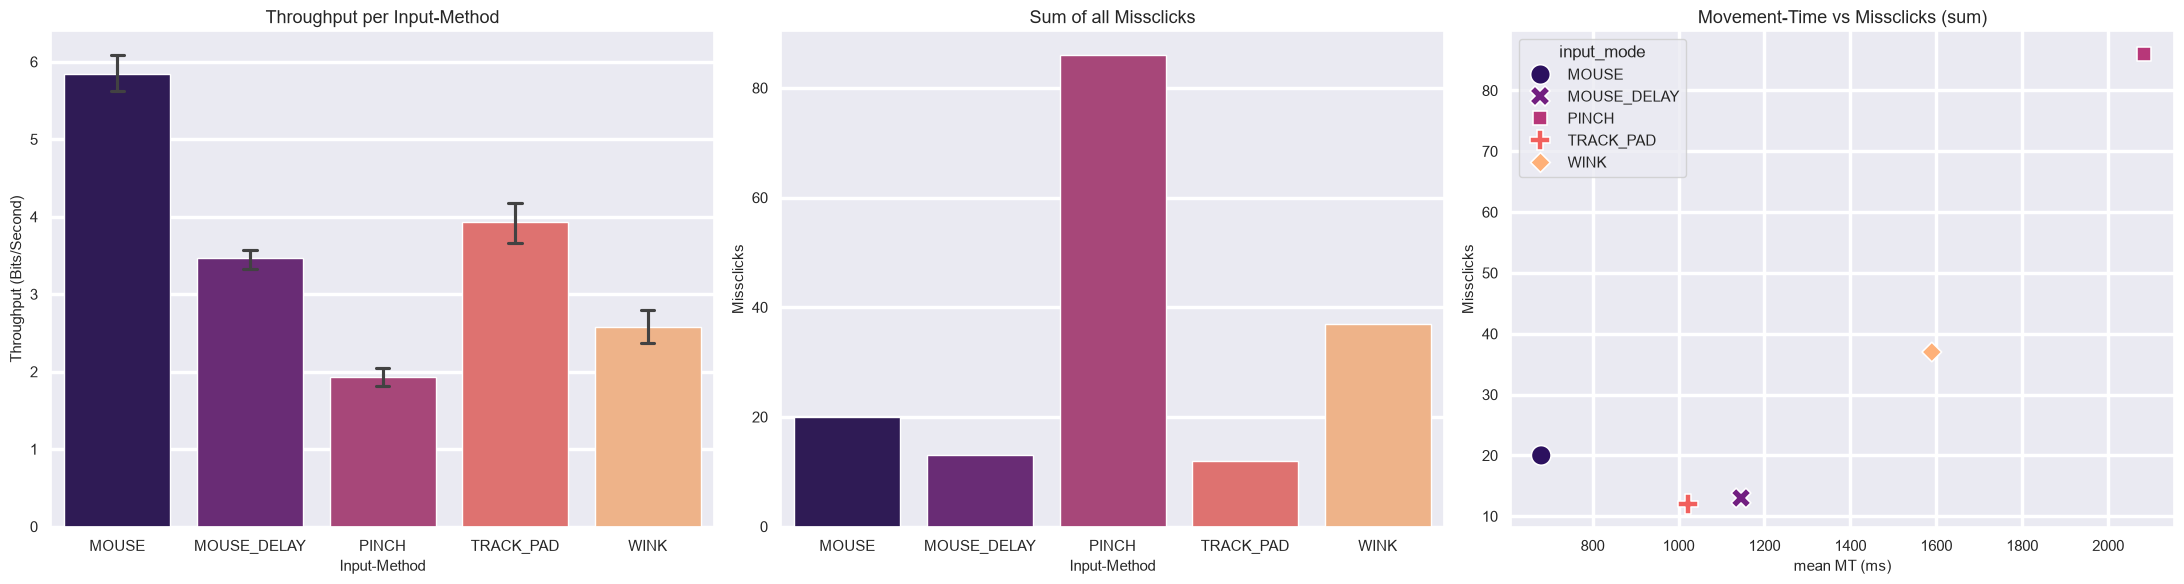

In [58]:
#Code for Comparison of Input-Methods
file_list = glob.glob(f"{fitts_Path}/**/*.csv", recursive=True)
all_data = []

for file in file_list:
    df = pd.read_csv(file, sep=";")
    
    df["mt"] = df.groupby(["pid", "iteration"])["timestamp"].transform(
        lambda x: x.diff()
    )
    df = df.dropna(subset=["mt"])
    all_data.append(df)

sorted_df = pd.concat(all_data, ignore_index=True)
sorted_df["ID"] = np.log2((2 * sorted_df["target_d"]) / sorted_df["target_w"])

#Especially here gemma-4 helped alot
#groups by conditions and calculates mt and missclicks for each group
input_summary = (
    sorted_df.groupby(["input_mode", "pid", "target_d", "target_w", "ID"])
    .agg(mt=("mt", "mean"), miss_clicks=("miss_clicks", "sum"))
    .reset_index()
)

#Then calculates the thoughput per group and sum of all misclicks per input method
input_summary["throughput"] = (input_summary["ID"] / input_summary["mt"]) * 1000
absolute_missclicks = (sorted_df.groupby("input_mode")["miss_clicks"].sum().reset_index())

sns.set_theme(style="darkgrid", rc={"grid.linewidth": 2.5})
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

#seaborn automatically calculates the mean of the groups
sns.barplot(
    ax=axes[0],
    data=input_summary,
    x="input_mode",
    y="throughput",
    palette="magma",
    hue="input_mode",
    capsize=0.1,
)
axes[0].set_title("Throughput per Input-Method", fontsize=13)
axes[0].set_xlabel("Input-Method", fontsize=11)
axes[0].set_ylabel("Throughput (Bits/Second)", fontsize=11)

sns.barplot(
    ax=axes[1],
    data=absolute_missclicks,
    x="input_mode",
    y="miss_clicks",
    palette="magma",
    hue="input_mode",
    #estimator=np.sum,
    #capsize=0.1
)
axes[1].set_title("Sum of all Missclicks", fontsize=13)
axes[1].set_xlabel("Input-Method", fontsize=11)
axes[1].set_ylabel("Missclicks", fontsize=11)

#gets only the mean/sum of all movementtimes and missclicks for the input-methods 
vs_data = (
    input_summary.groupby("input_mode")
    .agg(mean_mt=("mt", "mean"), total_misses=("miss_clicks", "sum"))
    .reset_index()
)

sns.scatterplot(
    ax=axes[2],
    data=vs_data,
    x="mean_mt",
    y="total_misses",
    hue="input_mode",
    style="input_mode",
    palette="magma",
    s=200,
)
axes[2].set_title("Movement-Time vs Missclicks (sum)", fontsize=13)
axes[2].set_xlabel("mean MT (ms)", fontsize=11)
axes[2].set_ylabel("Missclicks", fontsize=11)

plt.tight_layout()
plt.show()

# Steering Plots
Following the Plots for the analysis of Steering Law

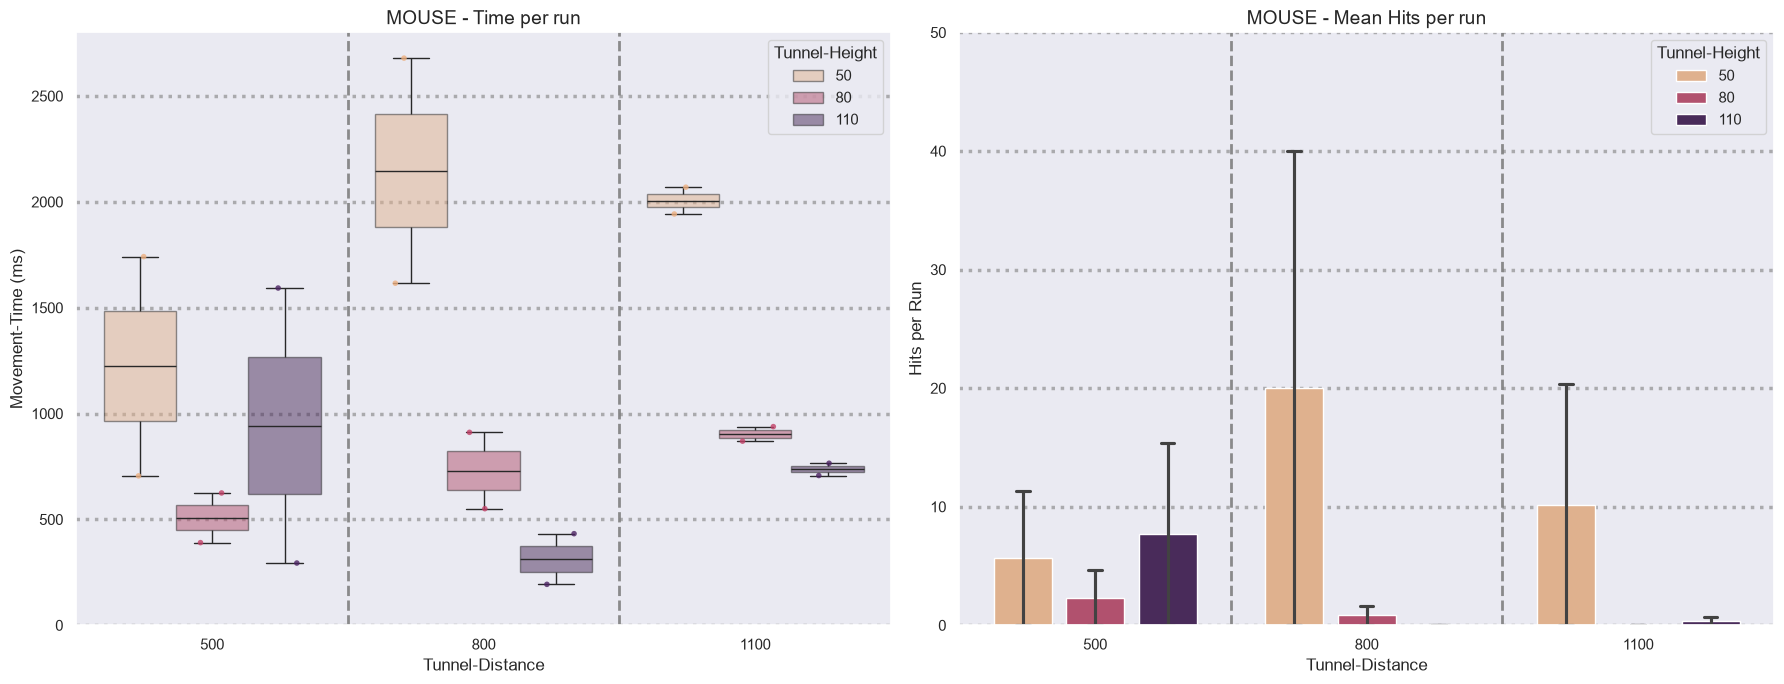

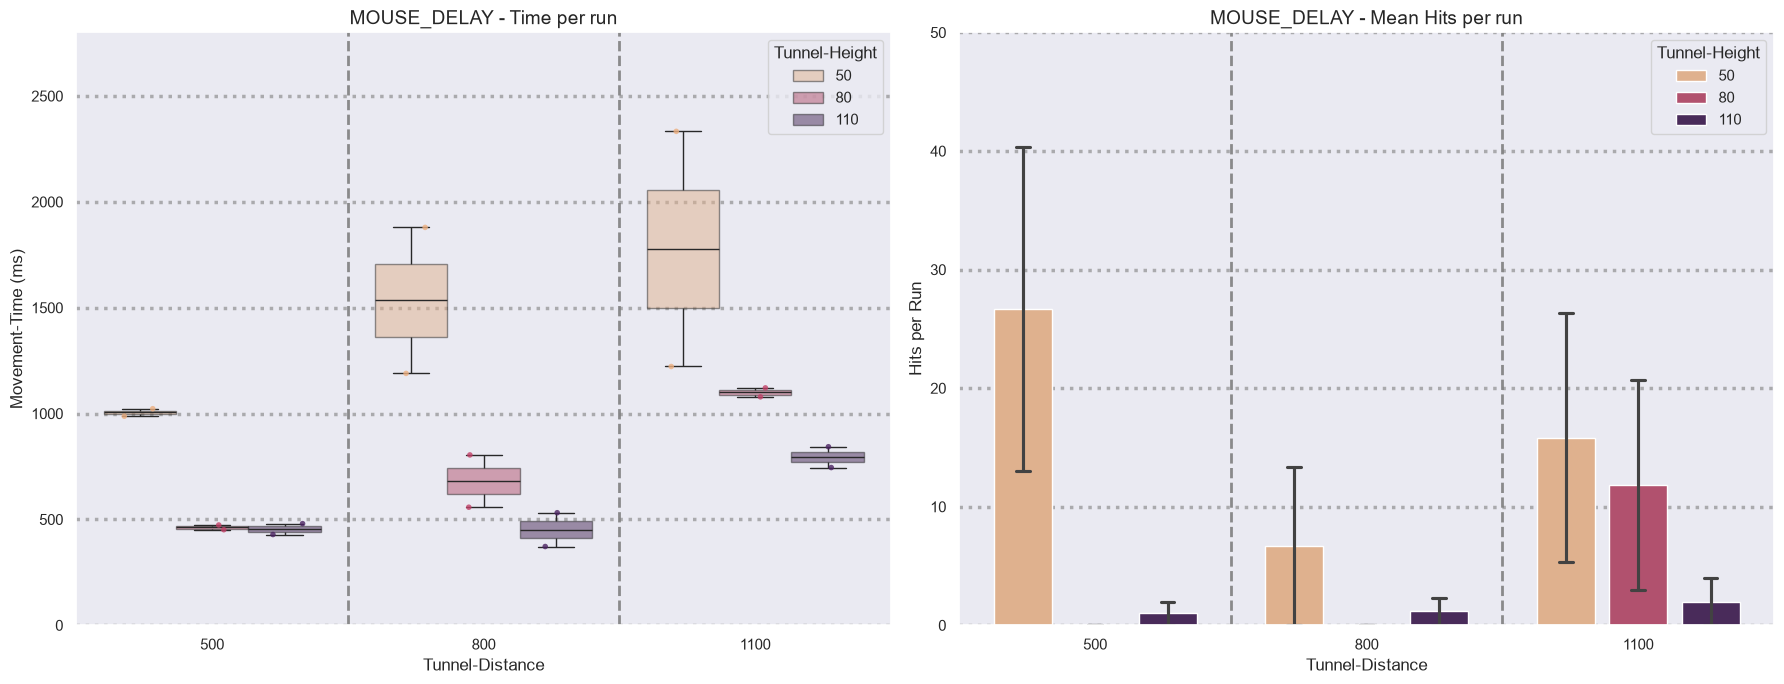

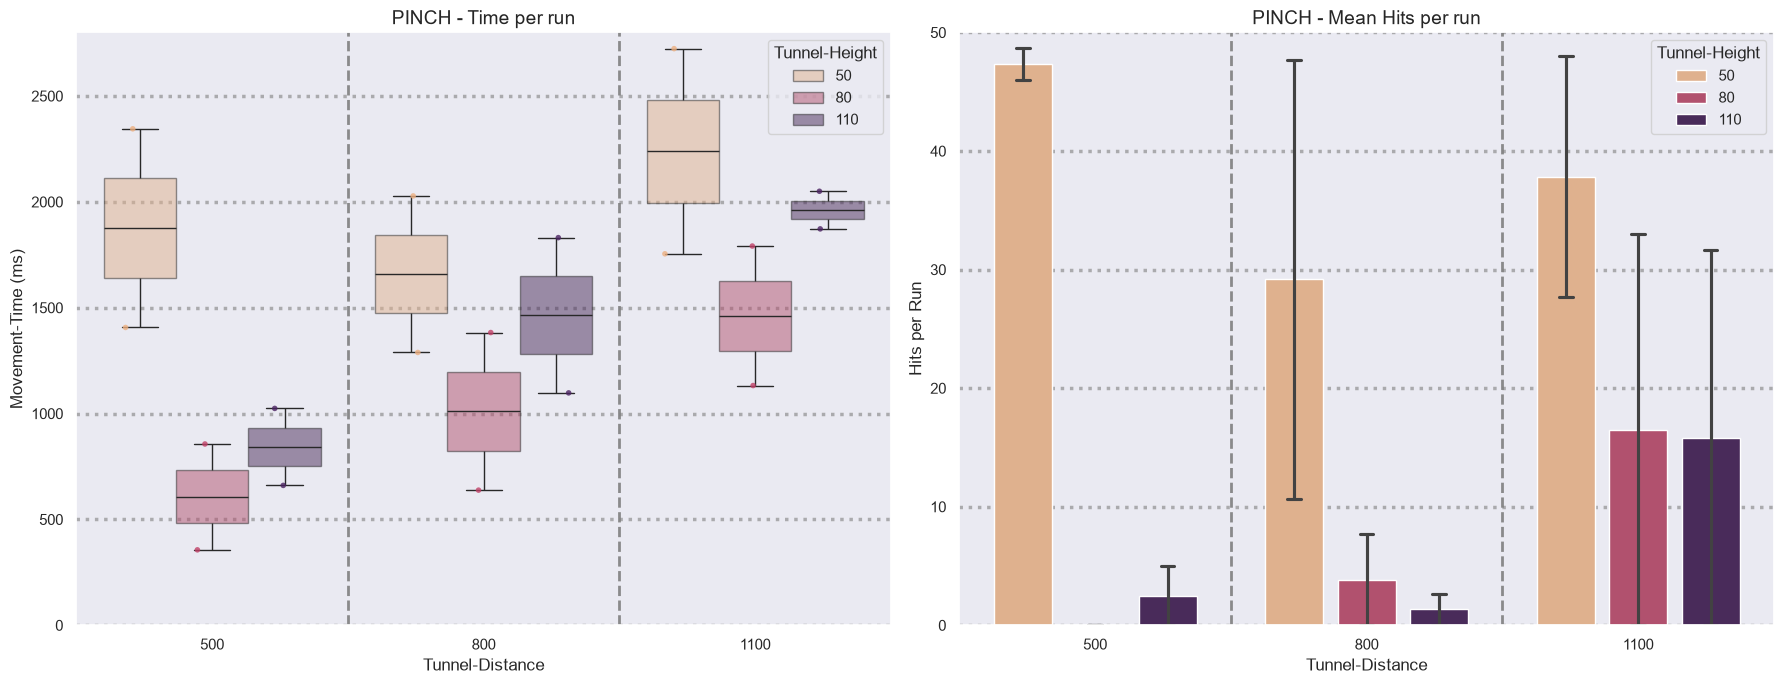

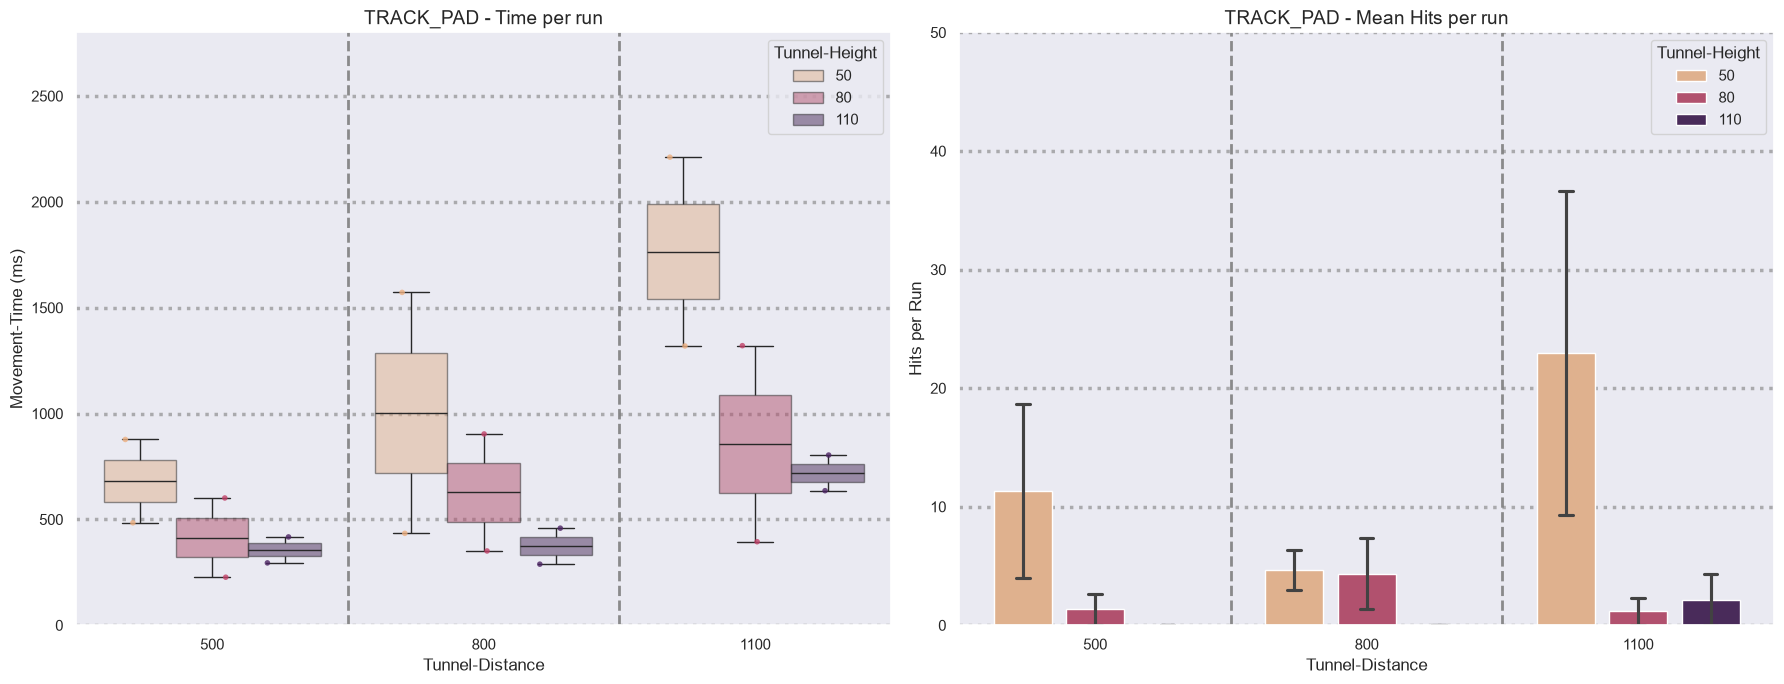

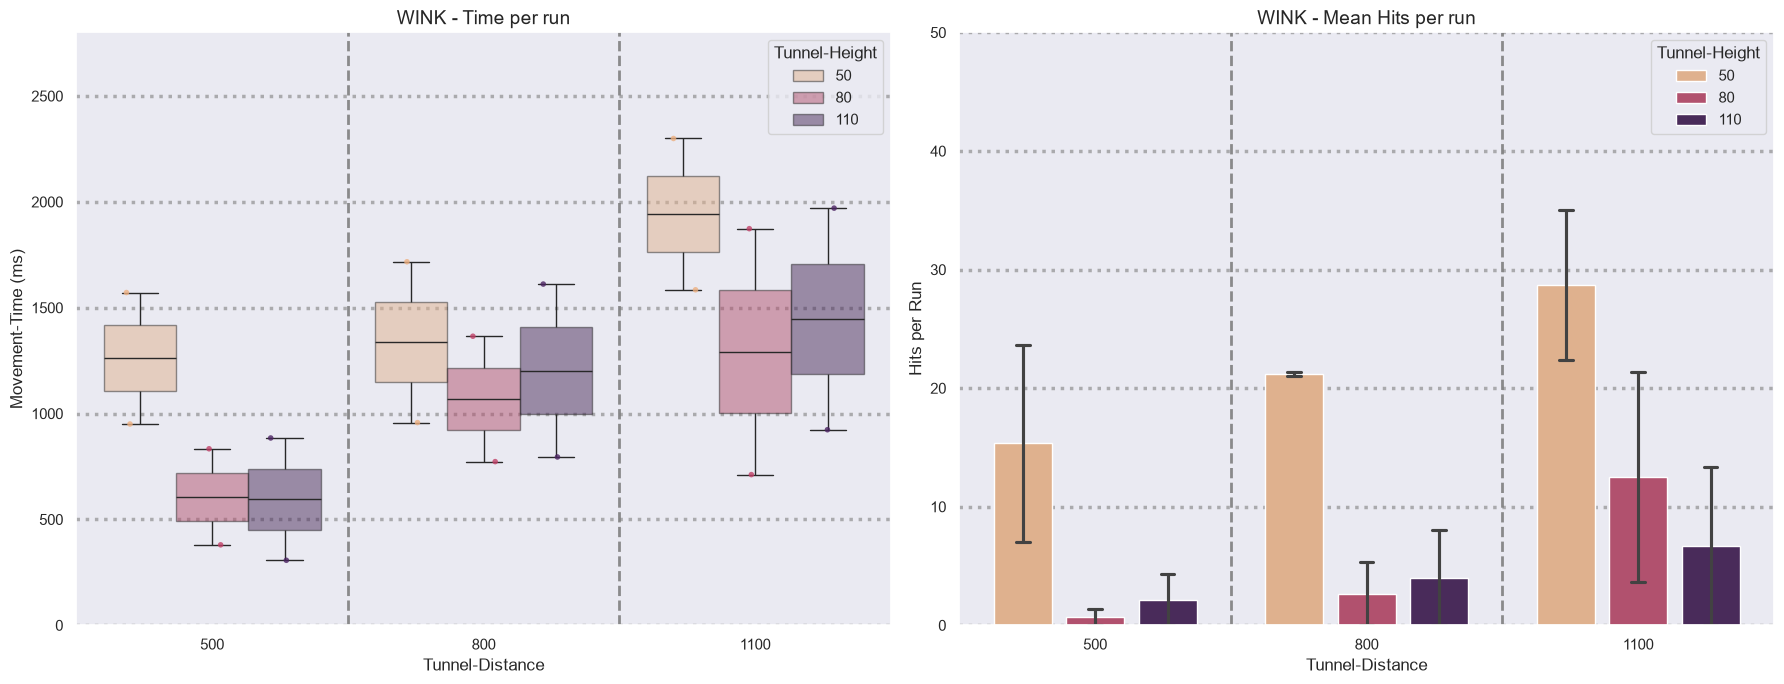

In [62]:
#Code for Input-Methods seperat
def showPlotPerInput(path):
    file_list = glob.glob(f"{path}/*.csv")
    all_data = []

    for file in file_list:
        df = pd.read_csv(file, sep=";")

        input_name = df["input_mode"][0]
        
        #instead of difference between each datapoint it's difference between first and last timestamp = total movementtime
        #for each file groups by pId and iteration and calculates difference between latest and earliest timestamp
        iteration_time = (
            df.groupby(["pid", "iteration"])["timestamp"]
            .agg(lambda x: (x.max() - x.min()))
            .reset_index()
        )

        #same but sum of hits
        iteration_hits = (
            df.groupby(["pid", "iteration"])["hit"].sum().reset_index()
        )

        #and add the specific conditions (is always same so just first)
        conditions = (
            df.groupby(["pid", "iteration"])[["tunnel_w", "tunnel_h"]]
            .first()
            .reset_index()
        )

        #then merge all into one table
        merged = pd.merge(iteration_time, iteration_hits, on=["pid", "iteration"])
        merged = pd.merge(merged, conditions, on=["pid", "iteration"])

        all_data.append(merged)

    sorted_df = pd.concat(all_data, ignore_index=True)

    user_target_df = (
        sorted_df.groupby(["pid", "tunnel_w", "tunnel_h"])["timestamp"]
        .mean()
        .reset_index()
    )

    user_errors_df = (
        sorted_df.groupby(["pid", "tunnel_w", "tunnel_h"])["hit"]
        .mean()
        .reset_index()
    )

    sns.set_theme(style="darkgrid", rc={"grid.linewidth": 2.5})
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    axes[0].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)
    sns.boxplot(
        ax=axes[0],
        data=user_target_df,
        x="tunnel_w",
        y="timestamp",
        hue="tunnel_h",
        palette="flare",
        showfliers=False,
        boxprops=dict(alpha=0.5, zorder=2),
    )
    sns.stripplot(
        ax=axes[0],
        data=user_target_df,
        x="tunnel_w",
        y="timestamp",
        hue="tunnel_h",
        palette="flare",
        alpha=0.8,
        size=4,
        jitter=0.2,
        dodge=True,
        legend=False,
        zorder=3,
    )
    for i in range(len(user_errors_df["tunnel_w"].unique()) - 1):
        axes[0].axvline(
            x=i + 0.5, color="gray", linestyle="--", alpha=0.9, linewidth=2
        )

    
    axes[0].set_title(f"{input_name} - Time per run", fontsize=14)
    axes[0].set_xlabel("Tunnel-Distance", fontsize=12)
    axes[0].set_ylabel("Movement-Time (ms)", fontsize=12)
    axes[0].set_ylim(0, 2800)
    axes[0].legend(title="Tunnel-Height", fontsize=11)

    axes[1].grid(True, linestyle=":", alpha=0.6, color="gray", zorder=0)
    sns.barplot(
        ax=axes[1],
        data=user_errors_df, 
        x="tunnel_w",
        y="hit",
        hue="tunnel_h",
        palette="flare",
        gap=0.2,
        capsize=0.15,
        zorder=2,
    )
    for i in range(len(user_errors_df["tunnel_w"].unique()) - 1):
        axes[1].axvline(
            x=i + 0.5, color="gray", linestyle="--", alpha=0.9, linewidth=2
        )

    axes[1].set_title(f"{input_name} - Mean Hits per run", fontsize=14)
    axes[1].set_xlabel("Tunnel-Distance", fontsize=12)
    axes[1].set_ylabel("Hits per Run", fontsize=12)
    axes[1].set_ylim(0,50)
    axes[1].legend(title="Tunnel-Height", fontsize=11)

    plt.tight_layout()
    plt.show()

if os.path.exists(steering_Path):
    for file in os.listdir(steering_Path):
        path = f"{steering_Path}/{file}"
        if os.path.isdir(path):
            showPlotPerInput(path)


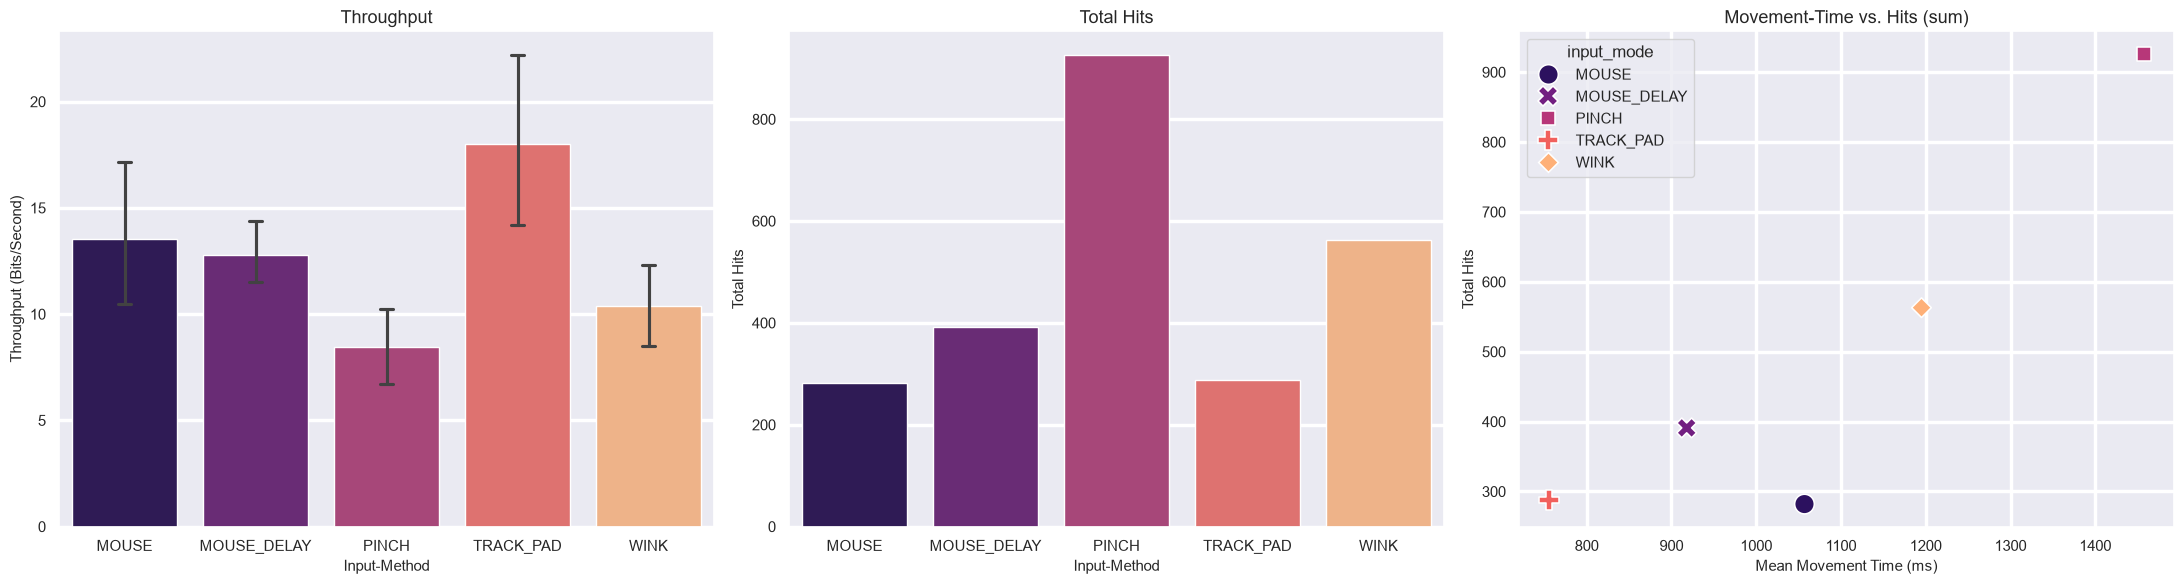

In [60]:
#Code for Comparison of Input-Methods
file_list = glob.glob(f"{steering_Path}/**/*.csv", recursive=True)
all_data = []

for file in file_list:
        df = pd.read_csv(file, sep=";")

        input_name = df["input_mode"][0]
        
        #instead of difference between each datapoint it's difference between first and last timestamp = total movementtime
        #for each file groups by pId and iteration and calculates difference between latest and earliest timestamp
        iteration_time = (
            df.groupby(["pid", "iteration"])["timestamp"]
            .agg(lambda x: (x.max() - x.min()))
            .reset_index()
        )

        #same but sum of hits
        iteration_hits = (
            df.groupby(["pid", "iteration"])["hit"].sum().reset_index()
        )

        #and add the specific conditions (is always same so just first)
        conditions = (
            df.groupby(["pid", "iteration"])[["input_mode","tunnel_w", "tunnel_h"]]
            .first()
            .reset_index()
        )

        #then merge all into one table
        merged = pd.merge(iteration_time, iteration_hits, on=["pid", "iteration"])
        merged = pd.merge(merged, conditions, on=["pid", "iteration"])

        all_data.append(merged)


sorted_df = pd.concat(all_data, ignore_index=True)
sorted_df["ID"] = sorted_df["tunnel_w"] / sorted_df["tunnel_h"]

input_summary = (
    sorted_df.groupby(["input_mode", "pid", "tunnel_w", "tunnel_h", "ID"])
    .agg(mt=("timestamp", "mean"), hits=("hit", "sum"))
    .reset_index()
)
input_summary["throughput"] = (input_summary["ID"] / input_summary["mt"]) * 1000

total_hits = (
    sorted_df.groupby("input_mode")["hit"].sum().reset_index()
)

sns.set_theme(style="darkgrid", rc={"grid.linewidth": 2.5})
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(
    ax=axes[0],
    data=input_summary,
    x="input_mode",
    y="throughput",
    palette="magma",
    hue="input_mode",
    capsize=0.1,
)
axes[0].set_title("Throughput", fontsize=13)
axes[0].set_xlabel("Input-Method", fontsize=11)
axes[0].set_ylabel("Throughput (Bits/Second)", fontsize=11)

sns.barplot(
    ax=axes[1],
    data=total_hits,
    x="input_mode",
    y="hit",
    palette="magma",
    hue="input_mode",
)
axes[1].set_title("Total Hits", fontsize=13)
axes[1].set_xlabel("Input-Method", fontsize=11)
axes[1].set_ylabel("Total Hits", fontsize=11)

scatter_data = (
    input_summary.groupby("input_mode")
    .agg(mean_mt=("mt", "mean"), total_misses=("hits", "sum"))
    .reset_index()
)

sns.scatterplot(
    ax=axes[2],
    data=scatter_data,
    x="mean_mt",
    y="total_misses",
    hue="input_mode",
    style="input_mode",
    palette="magma",
    s=200,
)
axes[2].set_title("Movement-Time vs. Hits (sum)", fontsize=13)
axes[2].set_xlabel("Mean Movement Time (ms)", fontsize=11)
axes[2].set_ylabel("Total Hits", fontsize=11)

plt.tight_layout()
plt.show()

# Results

___

## Fitts' Law
For better comparison:  
- set ylim of movement-times to 3800
- set ylim of missclicks to 30

#### Througput
Unsurprisingly the Mouse is still the best input-device by Througput.
But interestingly the mouse with delay was worse than the trackpad, even though participants reported getting used to the delay at the end and almost not feeling it anymore. So a second round or a longer warmup could improve the results.  
For gesture based input the Wink as click surpassed the Pinch of Thumb and indexfinger.

#### Missclicks
For Missclicks the Trackpad actually got the best result, followed by the delay.
One Explanation/Observation was that with more delay or the lower accuracy of the trackpad participants were more carefull navigating and as a result made less mistakes. That also shows on the plain Mouse, with big targets, since the participants got "overconfident" and often were so fast they overshot.
The Wink was alot better than the Pinch, which got twice as many missclicks.

#### Time vs Missclicks
The Mouse was the fastest with a few missclicks, while Delay and Trackpad are pretty close in both regards.
The Wink was both faster and less errorprone in comparrison to the Pinch.

#### Thoughts
The Mouse is the clear winner, though it had a few more missclicks the massive faster speed works in it's favor.  
The Delay and Trackpad are pretty close in all regard with the Trackpad having a slight edge over the delayed mouse.
For Gesture input the Wink is the favored method. The main explanation is that since the pointer is reliant on the middle of the two pinching fingers it needs some time getting used to, but is still prone to small movements. It did however improve with longer usage.  
The pointing via the sole index-finger was alot more accurate and intuitive and also didn't result in as much fatigue as the pinching.

---

### Steering Law
For better comparison:  
- set ylim of movement-times to 2800
- set ylim of hits to 50


#### Througput
Here the Track-pad actually took the crown, which could be due to the fast pointer acceleration and the clear parallel movement in comparison to the screen.
Interestingly Mouse and mouse with delay were very similar, which propably is due to the predictability and simplicity of the movement. Also the steering test was conducted after the fitts test so a learning effect could have taken place.  
The two gesture inputs were again pretty close with the Wink beeing better, which propably is due to the better predicitbility of the indexfinger...well it's literally called after it.

#### Hits
For Hits of the wall the Mouse was best, very close to the trackpad.
Here the Delay actually shows in a less acurate movement due to overcorrecting when getting off course.
The Wink is again much better than the Pinch which twice as many Wall hits.
It should be noted that depending on how the pyglet mouse-move-event works a faster movementspeed could automatically result in less hits. But as I was observing the tests the participants didn't really abuse this flaw if its even there.  
The big difference in Hits per participant can be explained since I tested the input-methods a bunch so i was more proficient, also the participant was pretty tired after the fitts' law test.

#### Time vs Hits
The Trackpad did best with a few more hits than the mouse but much faster speeds.
Second best was the mouse with delay which could be due to the delayed movement actually accelerating the movement through the tunnel since participants felt they were father behind than they actually were with the delay.
The Wink with the indexfinger as pointer was again much faster than the Pinch with the pointer between indexfinger and thumb, which should be because the indexfinger is literally used as a pointer in real life and therefore more accurate. Also the Tracking with mediapipe could result in jitters which could lead to more hits.


#### Thoughts
Surprisingly the Trackpad actually dominated this test, which is propably, like mentioned, in the nature of the paralell movement between screen and input-device.  
Also worth mentioning is that while Mouse with delay actually was faster than the plain mouse the latency resultet in a less accurate movement. Also the simplicity of the task explains the speed, with a twisted tunnel the results would propably be a lot different.  
Again the Wink with indexfinger was superior to the Pinch with index and thumb. Which is due to the nature of the indexfinger and technical problems of the tracking of indexfinger and thumb.

---

## Summary
Generally a strong learning effect could be observed while testing which doesn't refelct in the results.  
Overall the plain mouse is unbeat in diversity. But surpisingly gets beaten in specific circumstances like the steering test by sideeffects of latency and the limitations of a trackpad.  
The gesture inputs can't compete with the physical input-devices, but compared to eachother the Wink with Indexfinger surpasses the Pinch in most ways. Which is propably due to the overwhelming advantage the indexfinger has for pointing and the seperation of hand and face for clicks. It comes with other disadvantages which weren't recorded in the experiments.



---

# Problems
- Depending on the lighting-conditons mediapipe lost the hand when infront of the face
- For the **_Wink_**-Input-Method it was rare, but 2 or 3 times the hand blocked the cameras view of the eye, so the other needed to be used
- Fingers got fatigued with the **_PINCH_**-Gesture
- Not a problem perse, but the Trackpad on my Notebook sometimes decided to track my finger on the Buttons and sometimes don't (had left finger on the left-click button and used right hand to move the pointer)
- At one point the external participant thought i implemented an aimbot into the gestures since it worked so well for a time
- Winking didn't always work for different eyes, so it can be discriminating and should be refined if used (didn't want to change anything while trials were already done)
- Participants (rarely) shot over the finish line in steering test and crossed it from behind at times
- Should have implemented a warm-up round
